<a href="https://colab.research.google.com/github/Kritz11/taxi_trip_duration_prediction/blob/main/taxi_trip_duration_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
import pandas as pd

taxi = pd.read_csv('//content/drive/MyDrive/Colab Notebooks/nyc_taxi_trip_duration.csv')

taxi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729322 entries, 0 to 729321
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  729322 non-null  object 
 1   vendor_id           729322 non-null  int64  
 2   pickup_datetime     729322 non-null  object 
 3   dropoff_datetime    729322 non-null  object 
 4   passenger_count     729322 non-null  int64  
 5   pickup_longitude    729322 non-null  float64
 6   pickup_latitude     729322 non-null  float64
 7   dropoff_longitude   729322 non-null  float64
 8   dropoff_latitude    729322 non-null  float64
 9   store_and_fwd_flag  729322 non-null  object 
 10  trip_duration       729322 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 61.2+ MB


In [44]:
# from google.colab import drive
# drive.mount('/content/drive')

In [45]:
taxi['pickup_datetime'] = pd.to_datetime(taxi['pickup_datetime'])
taxi['dropoff_datetime'] = pd.to_datetime(taxi['dropoff_datetime'])

taxi.dtypes

,0
id,object
vendor_id,int64
pickup_datetime,datetime64[ns]
dropoff_datetime,datetime64[ns]
passenger_count,int64
pickup_longitude,float64
pickup_latitude,float64
dropoff_longitude,float64
dropoff_latitude,float64
store_and_fwd_flag,object


In [46]:
calculated_duration = (taxi['dropoff_datetime'] - taxi['pickup_datetime']).dt.total_seconds()

(calculated_duration == taxi['trip_duration']).value_counts()

,count
True,729322


In [47]:
taxi['trip_duration'].describe()

,trip_duration
count,7.293220e+05
mean,9.522291e+02
std,3.864626e+03
min,1.000000e+00
25%,3.970000e+02
50%,6.630000e+02
75%,1.075000e+03
max,1.939736e+06


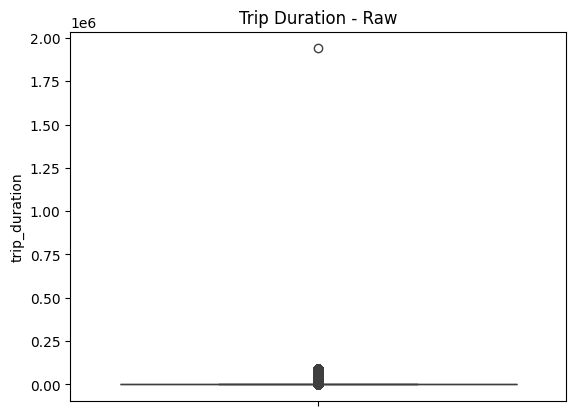

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(y=taxi['trip_duration'])
plt.title('Trip Duration - Raw')
plt.show()

In [49]:
taxi_clean = taxi[(taxi['trip_duration'] >= 120) & (taxi['trip_duration'] <= 21600)].copy()

print(f"Original rows: {len(taxi)}")
print(f"After removing impossible durations: {len(taxi_clean)}")
print(f"Rows removed: {len(taxi) - len(taxi_clean)}")

Original rows: 729322
After removing impossible durations: 714419
Rows removed: 14903


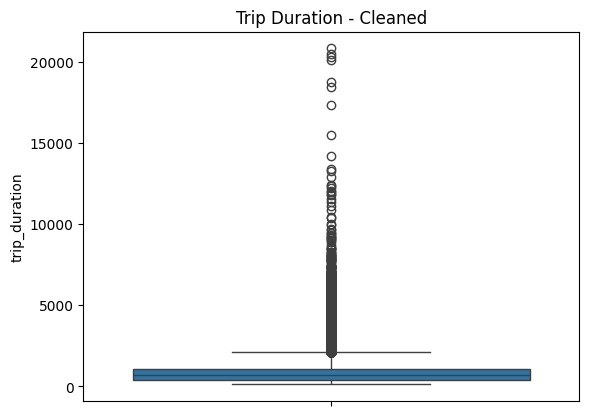

In [50]:
sns.boxplot(y=taxi_clean['trip_duration'])
plt.title('Trip Duration - Cleaned')
plt.show()

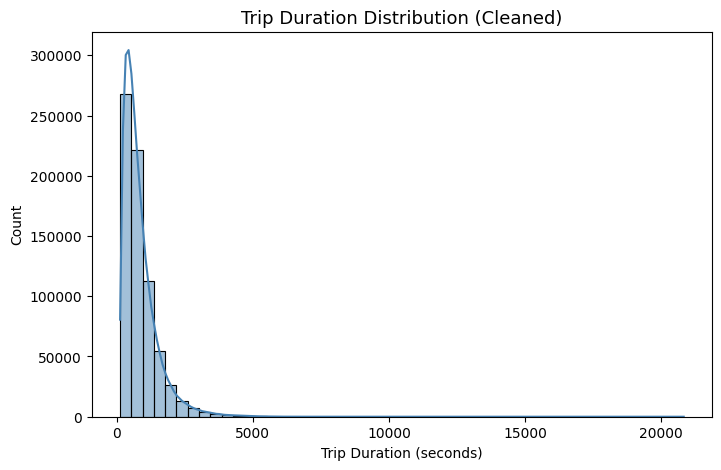

In [51]:
plt.figure(figsize=(8, 5))
sns.histplot(taxi_clean['trip_duration'], bins=50, kde=True, color='steelblue')
plt.title('Trip Duration Distribution (Cleaned)', fontsize=13)
plt.xlabel('Trip Duration (seconds)')
plt.show()

In [52]:
taxi_clean['pickup_hour'] = taxi_clean['pickup_datetime'].dt.hour
taxi_clean['pickup_day_of_week'] = taxi_clean['pickup_datetime'].dt.dayofweek
taxi_clean['pickup_month'] = taxi_clean['pickup_datetime'].dt.month

taxi_clean[['pickup_datetime', 'pickup_hour', 'pickup_day_of_week', 'pickup_month']].head()

,pickup_datetime,pickup_hour,pickup_day_of_week,pickup_month
0,2016-02-29 16:40:21,16,0,2
1,2016-03-11 23:35:37,23,4,3
2,2016-02-21 17:59:33,17,6,2
3,2016-01-05 09:44:31,9,1,1
4,2016-02-17 06:42:23,6,2,2


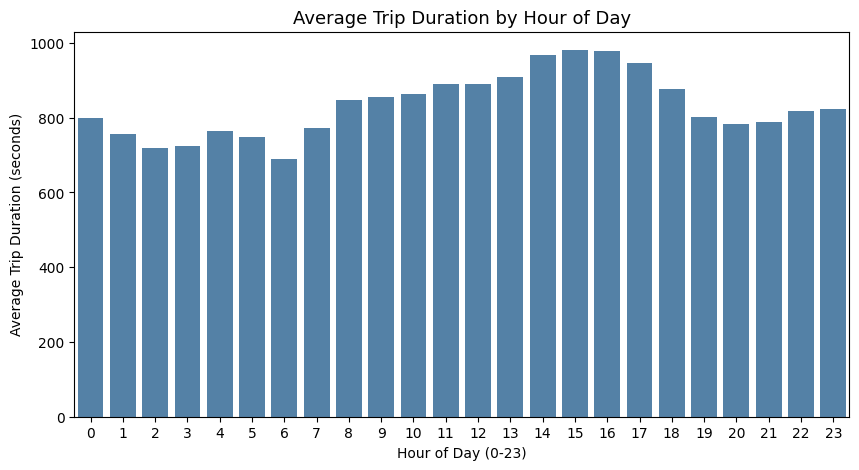

In [53]:
plt.figure(figsize=(10, 5))
sns.barplot(x='pickup_hour', y='trip_duration', data=taxi_clean, color='steelblue', errorbar=None)
plt.title('Average Trip Duration by Hour of Day', fontsize=13)
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Trip Duration (seconds)')
plt.show()

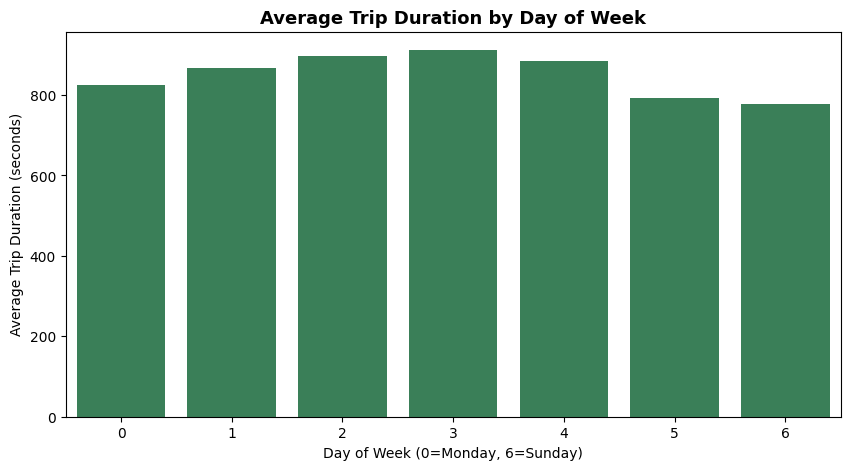

In [54]:
plt.figure(figsize=(10, 5))
sns.barplot(x='pickup_day_of_week', y='trip_duration', data=taxi_clean, color='seagreen', errorbar=None)
plt.title('Average Trip Duration by Day of Week', fontsize=13, fontweight='bold')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Average Trip Duration (seconds)')
plt.show()

In [55]:
import numpy as np

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in kilometers

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

taxi_clean['distance_km'] = haversine_distance(
    taxi_clean['pickup_latitude'], taxi_clean['pickup_longitude'],
    taxi_clean['dropoff_latitude'], taxi_clean['dropoff_longitude']
)

taxi_clean['distance_km'].describe()

,distance_km
count,714419.000000
mean,3.498186
std,4.368285
min,0.000000
25%,1.274177
50%,2.137354
75%,3.935565
max,1240.908677


In [56]:
taxi_clean = taxi_clean[(taxi_clean['distance_km'] >= 0.5) & (taxi_clean['distance_km'] <= 100)].copy()

In [57]:
print(f"Rows remaining: {len(taxi_clean)}")
taxi_clean['distance_km'].describe()

Rows remaining: 698128


,distance_km
count,698128.000000
mean,3.567187
std,3.967465
min,0.500002
25%,1.324139
50%,2.187347
75%,4.009880
max,97.586212


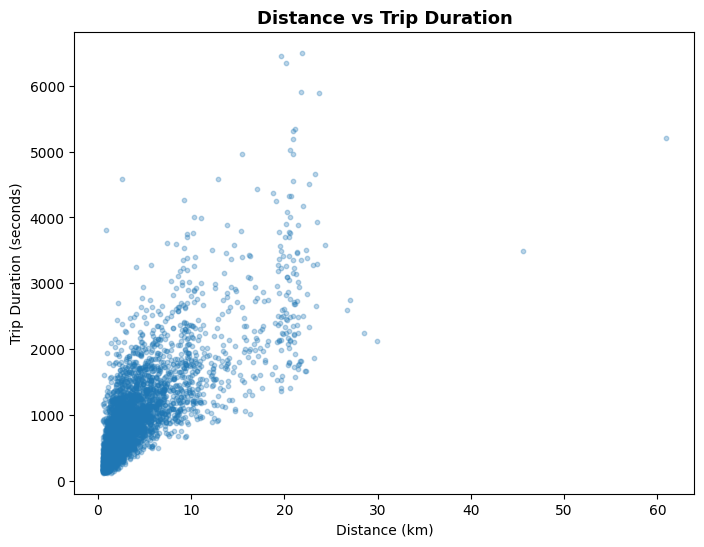

In [58]:
plt.figure(figsize=(8, 6))
sample = taxi_clean.sample(5000, random_state=42)  # just for a clearer plot, not all 698K points
plt.scatter(sample['distance_km'], sample['trip_duration'], alpha=0.3, s=10)
plt.xlabel('Distance (km)')
plt.ylabel('Trip Duration (seconds)')
plt.title('Distance vs Trip Duration', fontsize=13, fontweight='bold')
plt.show()

In [59]:
from sklearn.model_selection import train_test_split

feature_cols = ['distance_km', 'pickup_hour', 'pickup_day_of_week', 'pickup_month', 'passenger_count', 'vendor_id']

X = taxi_clean[feature_cols]
y = taxi_clean['trip_duration']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

Training rows: 558502
Testing rows: 139626


In [60]:
print(len(taxi_clean))

698128


In [61]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_pred[:10]

array([ 755.64240955, 1018.81602807,  782.26982144,  484.64077306,
       1013.62849233,  507.18368101,  551.26860427,  833.39047734,
        393.79238781,  620.35222856])

In [62]:
comparison = pd.DataFrame({
    'actual': y_test[:10].values,
    'predicted': y_pred[:10].round(1)
})
comparison['difference'] = (comparison['actual'] - comparison['predicted']).round(1)
comparison

,actual,predicted,difference
0,533,755.6,-222.6
1,2222,1018.8,1203.2
2,601,782.3,-181.3
3,381,484.6,-103.6
4,915,1013.6,-98.6
5,253,507.2,-254.2
6,459,551.3,-92.3
7,1636,833.4,802.6
8,156,393.8,-237.8
9,676,620.4,55.6


In [63]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f} seconds")
print(f"R² Score: {r2:.4f}")

RMSE: 422.12 seconds
R² Score: 0.5894


In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [65]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

print(f"KNN RMSE: {rmse_knn:.2f} seconds")
print(f"KNN R² Score: {r2_knn:.4f}")

KNN RMSE: 381.80 seconds
KNN R² Score: 0.6641


In [66]:
k_values = [3, 5, 10, 15, 20, 30]
knn_results = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    preds = knn.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    knn_results.append({'k': k, 'rmse': rmse, 'r2': r2})
    print(f"K={k}: RMSE={rmse:.2f}, R²={r2:.4f}")

K=3: RMSE=403.40, R²=0.6250
K=5: RMSE=381.80, R²=0.6641
K=10: RMSE=367.10, R²=0.6894
K=15: RMSE=362.96, R²=0.6964
K=20: RMSE=360.83, R²=0.7000
K=30: RMSE=359.10, R²=0.7028


In [67]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:.2f} seconds")
print(f"Random Forest R² Score: {r2_rf:.4f}")

Random Forest RMSE: 373.02 seconds
Random Forest R² Score: 0.6793


In [ ]:
from sklearn.model_selection import GridSearchCV

X_train_sample = X_train.sample(50000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 10]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=2
)

grid_search.fit(X_train_sample, y_train_sample)

print(f"Best parameters: {grid_search.best_params_}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END .max_depth=10, min_samples_split=2, n_estimators=50; total time=   4.0s
[CV] END .max_depth=10, min_samples_split=2, n_estimators=50; total time=   2.5s
[CV] END .max_depth=10, min_samples_split=2, n_estimators=50; total time=   2.6s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   5.6s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   6.8s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   5.1s
[CV] END max_depth=10, min_samples_split=10, n_estimators=50; total time=   2.6s
[CV] END max_depth=10, min_samples_split=10, n_estimators=50; total time=   4.4s
[CV] END max_depth=10, min_samples_split=10, n_estimators=50; total time=   2.8s
[CV] END max_depth=10, min_samples_split=10, n_estimators=100; total time=   5.0s
[CV] END max_depth=10, min_samples_split=10, n_estimators=100; total time=   6.3s
[CV] END max_depth=10, min_samples_split=10, n

In [ ]:
rf_tuned = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

y_pred_rf_tuned = rf_tuned.predict(X_test)

rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

print(f"Tuned Random Forest RMSE: {rmse_rf_tuned:.2f} seconds")
print(f"Tuned Random Forest R² Score: {r2_rf_tuned:.4f}")

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print(f"Gradient Boosting RMSE: {rmse_gb:.2f} seconds")
print(f"Gradient Boosting R² Score: {r2_gb:.4f}")

In [ ]:
param_grid_gb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5]
}

grid_search_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gb,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=2
)

grid_search_gb.fit(X_train_sample, y_train_sample)

print(f"Best parameters: {grid_search_gb.best_params_}")

In [ ]:
gb_tuned = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

gb_tuned.fit(X_train, y_train)

y_pred_gb_tuned = gb_tuned.predict(X_test)

rmse_gb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_gb_tuned))
r2_gb_tuned = r2_score(y_test, y_pred_gb_tuned)

print(f"Tuned Gradient Boosting RMSE: {rmse_gb_tuned:.2f} seconds")
print(f"Tuned Gradient Boosting R² Score: {r2_gb_tuned:.4f}")

In [ ]:
from sklearn.ensemble import VotingRegressor

rf_for_voting = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_split=10, random_state=42, n_jobs=-1)
gb_for_voting = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
knn_for_voting = KNeighborsRegressor(n_neighbors=30)

voting_model = VotingRegressor([
    ('rf', rf_for_voting),
    ('gb', gb_for_voting),
    ('knn', knn_for_voting)
])

voting_model.fit(X_train_scaled, y_train)

y_pred_voting = voting_model.predict(X_test_scaled)

rmse_voting = np.sqrt(mean_squared_error(y_test, y_pred_voting))
r2_voting = r2_score(y_test, y_pred_voting)

print(f"Voting Ensemble RMSE: {rmse_voting:.2f} seconds")
print(f"Voting Ensemble R² Score: {r2_voting:.4f}")